In [1]:
import os
import numpy as np
import xarray as xr
import pandas as pd
import seaborn as sns
import geopandas as gpd

import cartopy.crs as ccrs
import scipy.stats as stats
import cartopy.feature as cfeature

import shapely.vectorized as sv

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.colors as mcolors
from matplotlib.colors import BoundaryNorm

import shapely.geometry as sg
from shapely.geometry import Point

from sklearn.linear_model import LinearRegression

import sys
sys.path.append(os.path.abspath(".."))
from function import DOWN_raw
from function import ART_preprocessing as ART_pre

from playsound import playsound

import warnings
warnings.filterwarnings('ignore')

playsound is relying on another python subprocess. Please use `pip install pygobject` if you want playsound to run more efficiently.


In [2]:
dir_base = os.path.join('/', 'media', 'arturo', 'T9', 'Data', 'Italy')

## Code to obtain the Mean of Seeds only for the Ensemble Median

In [3]:
lon_min, lon_max, lat_min, lat_max, area, toll = 6.5, 19, 36.5, 48, 'ITALY', 0.002

veneto_dir = os.path.join('/','media','arturo','T9','Data','shapes','Europa','Italy')

if os.path.exists(veneto_dir):
    REGIONS = gpd.read_file(os.path.join(veneto_dir,'Italy_regions.geojson'))
    ITALY = gpd.read_file(os.path.join(veneto_dir,'Italy_clear.geojson'))
else:
    raise SystemExit(f"File not found: {veneto_dir}")

italy_geom = ITALY.union_all()

## OBS data

In [4]:
Tr = [5,  10,  20,  50, 100, 200]
Fi = 1 - 1/np.array(Tr)

if os.path.exists(veneto_dir):
    REGIONS = gpd.read_file(os.path.join(veneto_dir,'Italy_regions.geojson'))
else:
    raise SystemExit(f"File not found: {veneto_dir}")

obs_base = os.path.join('/','media','arturo','T9','Data','Italy','Rain_Gauges_QC')
bias_base = os.path.join('/','media','arturo','T9','Data','Italy','Satellite','6_DOWN_BCorrected','TEST')

METADATA = pd.read_csv(os.path.join(obs_base, 'data', 'METADATA', 'METADATA_FTS_QCv4_Case1_wAIRHO_v3_1dy.csv'))
METADATA["Lat"] = np.round(METADATA["Lat"], 6)
METADATA["Lon"] = np.round(METADATA["Lon"], 6)

ISO_names = np.unique(METADATA.ISO.values)

lats, lons = [], []
QUANTILE = []

for rr in range(len(ISO_names)):
    region_ISO = ISO_names[rr]

    INFO_dict = {}
    WEIBULL_dict = {}
    QUANTILES_dict = {}

    # print(f'{rr+1}: {region_ISO}')

    METADATA_clear = METADATA[METADATA['ISO']==region_ISO].reset_index(inplace=False)

    for nn in range(len(METADATA_clear)):#len(METADATA_clear)
        filename = f'{METADATA_clear['File'].values[nn]}'
        lat_obs = METADATA_clear['Lat'][nn]
        lon_obs = METADATA_clear['Lon'][nn]
        elev_obs = METADATA_clear['DEM_Elevation'][nn]

        OBS_pd = pd.read_csv(os.path.join(obs_base, 'Weibull', '1dy', region_ISO, filename))
        OBS_pd = OBS_pd[(OBS_pd['Year']>=2002)&(OBS_pd['Year']<=2023)].reset_index(drop=True)
        
        if len(OBS_pd) == 0:
            continue

        else:
            OBS_N = OBS_pd['N'].values
            OBS_C = OBS_pd['C'].values
            OBS_W = OBS_pd['W'].values
            OBS_Y = OBS_pd['Year'].values

            mask = ~np.isnan(OBS_N)

            OBS_N = OBS_N[mask]
            OBS_C = OBS_C[mask]
            OBS_W = OBS_W[mask]
            OBS_Y = OBS_Y[mask]

            if len(OBS_Y) >= 8: # greather than 8 years

                x0 = np.nanmean(OBS_C)
                OBS_Q, flag = DOWN_raw.mev_quant_update(Fi, x0, OBS_N, OBS_C, OBS_W, thresh=1)
                OBS_Q2 = np.where(flag, OBS_Q, np.nan)

                lats.append(lat_obs)
                lons.append(lon_obs)
                QUANTILE.append(OBS_Q2[3])

Quantile_pd = pd.DataFrame({'lat':lats,'lon':lons,'Quantile':QUANTILE})
Quantile_clear = Quantile_pd[Quantile_pd['Quantile']<500]
Q_norm = (Quantile_clear['lat'].values - np.nanmin(Quantile_clear['lat'].values))/(np.nanmax(Quantile_clear['lat'].values)-np.nanmin(Quantile_clear['lat'].values)) *2

## Original QUANTILES DOWNSCALED

In [5]:
ENS_base = os.path.join('/','media','arturo','T9','Data','Italy','Satellite','5_ENSEMBLE')

dir_in = os.path.join(ENS_base,f'ITALY_ENSEMBLE_ALL_1dy_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson_median.nc')
DATA = xr.open_dataset(dir_in)
lon2d, lat2d, = np.meshgrid(DATA.lon, DATA.lat)
mask_italy = sv.contains(italy_geom, lon2d, lat2d)

MEVd_Median = DATA.Mev_d.where(mask_italy)

## CORRECTED DATA

In [6]:
# seeds_list = [7, 19, 31, 53, 89, 127, 211, 307, 401, 509, 613, 727, 839, 947, 1051]
seeds_list = [7, 19, 31, 53, 89, 127, 211, 307]

### Quantiles correction using parameters and Relatives Errors

In [7]:
ENS_base = os.path.join('/','media','arturo','T9','Data','Italy','Satellite','6_DOWN_BCorrected','PARAM','LTO')

MEVd_Median_QQc = np.zeros([len(seeds_list),240,260])
MEVd_Median_LLc = np.zeros([len(seeds_list),240,260])
MEVd_Median_LTO = np.zeros([len(seeds_list),240,260])
MEVd_Median_LSc = np.zeros([len(seeds_list),240,260])

nn = 0
for seed in seeds_list:
    print(f'Seed: {seed}')
    dir_in = os.path.join(ENS_base,f'ITALY_DOWN_ENSEMBLE_median_1dy_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson_LTO_{str(seed).zfill(4)}.nc')
    DATA = xr.open_dataset(dir_in)  
    mask_italy = sv.contains(italy_geom, lon2d, lat2d)

    # MEVd_Median_QQc[nn,:,:] = DATA.MEVd_QQc.where(mask_italy)
    # MEVd_Median_LLc[nn,:,:] = DATA.MEVd_LLc.where(mask_italy)
    MEVd_Median_LTO[nn,:,:] = DATA.Mev_d[3,:,:].where(mask_italy)
    # MEVd_Median_LSc[nn,:,:] = DATA.MEVd_LSc.where(mask_italy)

    nn = nn + 1

# Median of all seeds
# MEVd_QQc_PARAM = np.nanmedian(MEVd_Median_QQc,axis=0)
# MEVd_LLc_PARAM = np.nanmedian(MEVd_Median_LLc,axis=0)
MEVd_LTO_PARAM = np.nanmedian(MEVd_Median_LTO,axis=0)
# MEVd_LSc_PARAM = np.nanmedian(MEVd_Median_LSc,axis=0)

Seed: 7
Seed: 19
Seed: 31
Seed: 53
Seed: 89
Seed: 127
Seed: 211
Seed: 307


In [8]:
# dir_in = os.path.join('/','media','arturo','T9','Data','Italy','Bias_series','QUANTILES',f'Bias_RE_{str(seed).zfill(4)}.csv')
# DF_RE = pd.read_csv(dir_in)

dir_in = os.path.join(dir_base,'Bias_series','PARAM',f'Bias_stats_QQc_{str(seed).zfill(4)}.csv')
RSR_PARAM_QQc = pd.read_csv(dir_in)

dir_in = os.path.join(dir_base,'Bias_series','PARAM',f'Bias_stats_LLc_{str(seed).zfill(4)}.csv')
RSR_PARAM_LLc = pd.read_csv(dir_in)

dir_in = os.path.join(dir_base,'Bias_series','PARAM',f'Bias_stats_LTO_{str(seed).zfill(4)}.csv')
RSR_PARAM_LTO = pd.read_csv(dir_in)

dir_in = os.path.join(dir_base,'Bias_series','PARAM',f'Bias_stats_LSc_{str(seed).zfill(4)}.csv')
RSR_PARAM_LSc = pd.read_csv(dir_in)

In [9]:
# ENSEMBLE_group_PARAM = np.zeros([len(seeds_list), 806])
ENSEMBLE_group_PARAM = []
nn = 0
for seed in seeds_list:
    print(f'Seed: {seed}')
    dir_in = os.path.join(dir_base,'Bias_series','PARAM',f'Bias_RE_{str(seed).zfill(4)}.csv')
    tmp = pd.read_csv(dir_in)
    # ENSEMBLE_group_PARAM[nn,:] = tmp.ENSEMBLE_MEDIAN_LTO.values
    ENSEMBLE_group_PARAM.append(tmp.ENSEMBLE_MEDIAN_LTO.values)

    nn = nn + 1

Seed: 7
Seed: 19
Seed: 31
Seed: 53
Seed: 89
Seed: 127
Seed: 211
Seed: 307


### QUANTILES correction using quantiles and Relative Errors

In [10]:
ENS_base = os.path.join('/','media','arturo','T9','Data','Italy','Satellite','6_DOWN_BCorrected','QUANTILE')

MEVd_Median_QQc = np.zeros([len(seeds_list),240,260])
MEVd_Median_LLc = np.zeros([len(seeds_list),240,260])
MEVd_Median_LTO = np.zeros([len(seeds_list),240,260])
MEVd_Median_LSc = np.zeros([len(seeds_list),240,260])

nn = 0
for seed in seeds_list:
    print(f'Seed: {seed}')
    dir_in = os.path.join(ENS_base,f'ITALY_DOWN_ENSEMBLE_median_1dy_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson_QQc_LLc_{str(seed).zfill(4)}.nc')
    DATA = xr.open_dataset(dir_in)
    mask_italy = sv.contains(italy_geom, lon2d, lat2d)

    MEVd_Median_QQc[nn,:,:] = DATA.MEVd_QQc.where(mask_italy)
    MEVd_Median_LLc[nn,:,:] = DATA.MEVd_LLc.where(mask_italy)
    MEVd_Median_LTO[nn,:,:] = DATA.MEVd_LTO.where(mask_italy)
    MEVd_Median_LSc[nn,:,:] = DATA.MEVd_LSc.where(mask_italy)

    nn = nn + 1

# Median of all seeds
MEVd_QQc_QUANTILES = np.nanmedian(MEVd_Median_QQc,axis=0)
MEVd_LLc_QUANTILES = np.nanmedian(MEVd_Median_LLc,axis=0)
MEVd_LTO_QUANTILES = np.nanmedian(MEVd_Median_LTO,axis=0)
MEVd_LSc_QUANTILES = np.nanmedian(MEVd_Median_LSc,axis=0)

Seed: 7
Seed: 19
Seed: 31
Seed: 53
Seed: 89
Seed: 127
Seed: 211
Seed: 307


In [11]:
# dir_in = os.path.join(dir_base,'Bias_series','QUANTILES',f'Bias_RE_{str(seed).zfill(4)}.csv')
# DF_QUANTILES = pd.read_csv(dir_in)

dir_in = os.path.join(dir_base,'Bias_series','QUANTILES',f'Bias_stats_QQc_{str(seed).zfill(4)}.csv')
RSR_QUANTILE_QQc = pd.read_csv(dir_in)

dir_in = os.path.join(dir_base,'Bias_series','QUANTILES',f'Bias_stats_LLc_{str(seed).zfill(4)}.csv')
RSR_QUANTILE_LLc = pd.read_csv(dir_in)

dir_in = os.path.join(dir_base,'Bias_series','QUANTILES',f'Bias_stats_LTO_{str(seed).zfill(4)}.csv')
RSR_QUANTILE_LTO = pd.read_csv(dir_in)

dir_in = os.path.join(dir_base,'Bias_series','QUANTILES',f'Bias_stats_LSc_{str(seed).zfill(4)}.csv')
RSR_QUANTILE_LSc = pd.read_csv(dir_in)

In [12]:
ENSEMBLE_group_QUANTILES = np.zeros([len(seeds_list), 808])

nn = 0
for seed in seeds_list:
    print(f'Seed: {seed}')
    dir_in = os.path.join('/','media','arturo','T9','Data','Italy','Bias_series','QUANTILES',f'Bias_RE_{str(seed).zfill(4)}.csv')
    tmp = pd.read_csv(dir_in)
    ENSEMBLE_group_QUANTILES[nn,:] = tmp.ENSEMBLE_MEDIAN_LTO.values

    nn = nn + 1

Seed: 7
Seed: 19
Seed: 31
Seed: 53
Seed: 89
Seed: 127
Seed: 211
Seed: 307


In [13]:
ENS_base = os.path.join('/','media','arturo','T9','Data','Italy','Satellite','6_DOWN_BCorrected','QUANTILE')

MEVd_Median_QQc = np.zeros([len(seeds_list),240,260])
MEVd_Median_LLc = np.zeros([len(seeds_list),240,260])
MEVd_Median_LTO = np.zeros([len(seeds_list),240,260])
MEVd_Median_LSc = np.zeros([len(seeds_list),240,260])

nn = 0
for seed in seeds_list:
    print(f'Seed: {seed}')
    dir_in = os.path.join(ENS_base,f'ITALY_DOWN_ENSEMBLEd_median_1dy_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson_QQc_LLc_{str(seed).zfill(4)}.nc')
    DATA = xr.open_dataset(dir_in)
    mask_italy = sv.contains(italy_geom, lon2d, lat2d)

    MEVd_Median_QQc[nn,:,:] = DATA.MEVd_QQc.where(mask_italy)
    MEVd_Median_LLc[nn,:,:] = DATA.MEVd_LLc.where(mask_italy)
    MEVd_Median_LTO[nn,:,:] = DATA.MEVd_LTO.where(mask_italy)
    MEVd_Median_LSc[nn,:,:] = DATA.MEVd_LSc.where(mask_italy)

    nn = nn + 1

# Median of all seeds
MEVd_QQc_PARAM = np.nanmedian(MEVd_Median_QQc,axis=0)
MEVd_LLc_PARAM = np.nanmedian(MEVd_Median_LLc,axis=0)
MEVd_LTO_PARAM = np.nanmedian(MEVd_Median_LTO,axis=0)
MEVd_LSc_PARAM = np.nanmedian(MEVd_Median_LSc,axis=0)

Seed: 7
Seed: 19
Seed: 31
Seed: 53
Seed: 89
Seed: 127
Seed: 211
Seed: 307


Text(0.0, 1.0, 'LTO relative error distributions')

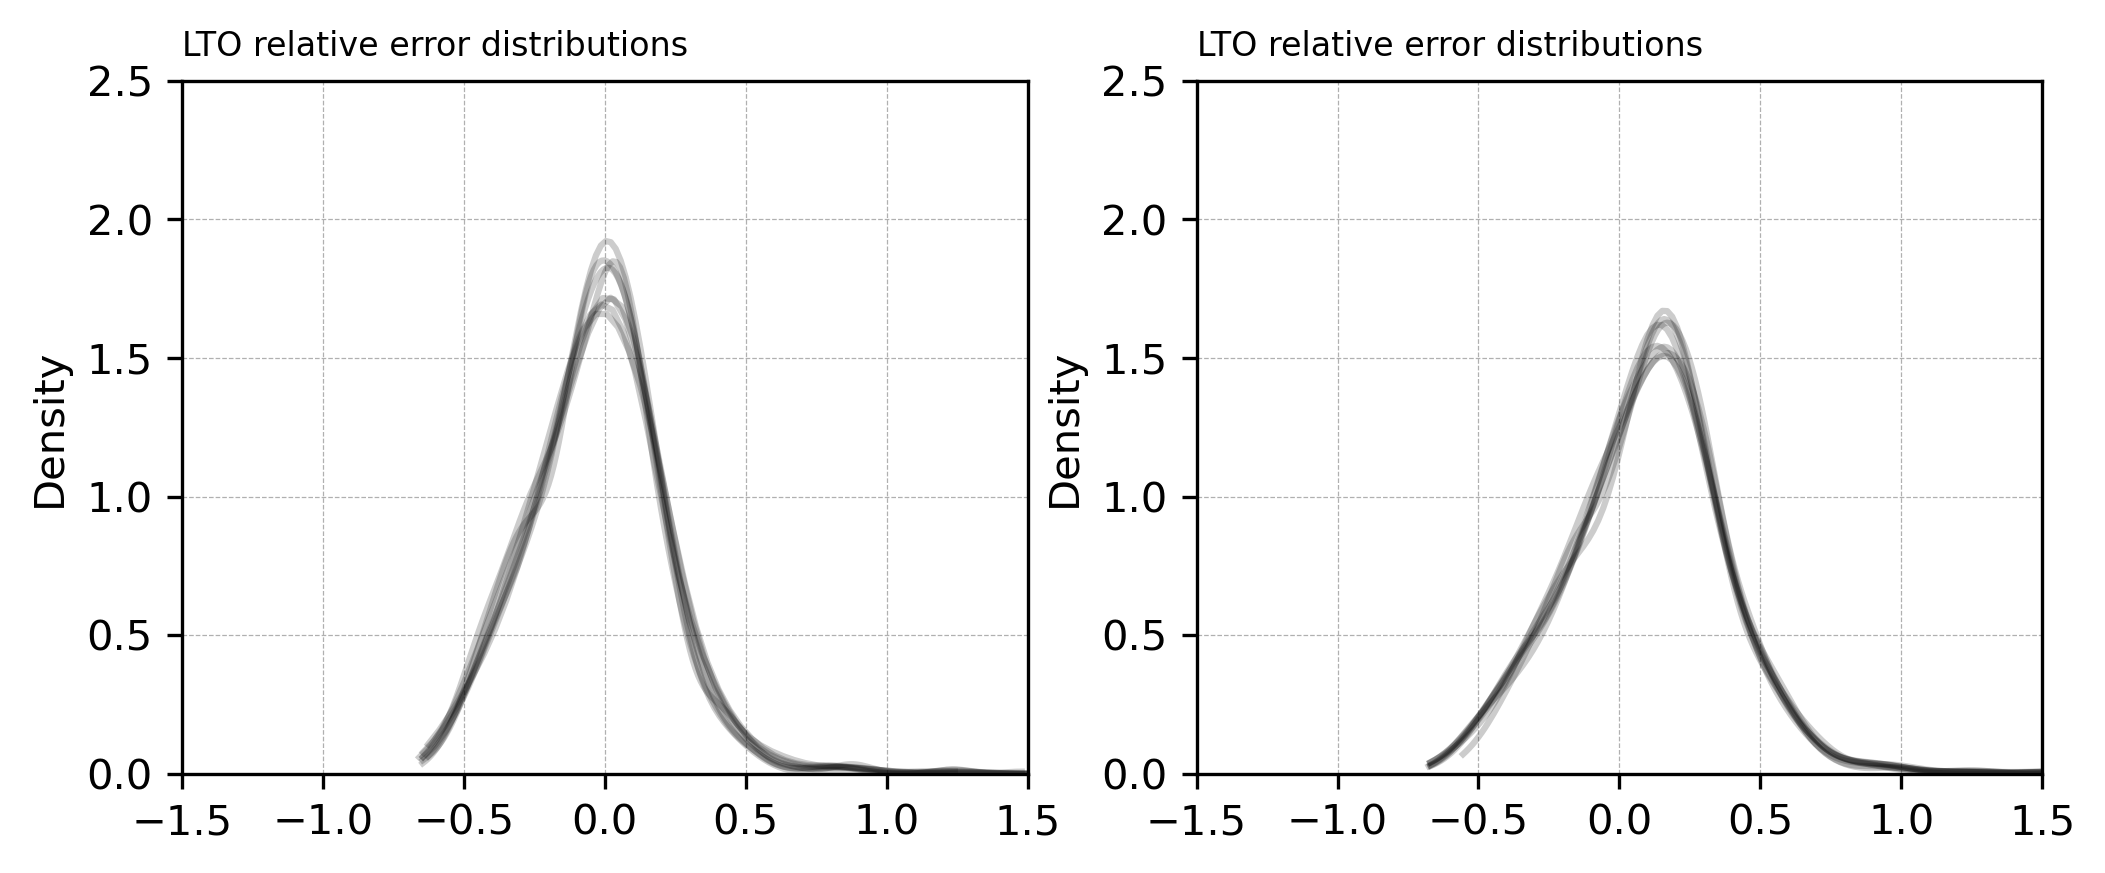

In [14]:
fig = plt.figure(figsize=(8,3),dpi=300)
gs = gridspec.GridSpec(1,2)

# ===========================================================================================================================================================================
# ===========================================================================================================================================================================
ax1 = plt.subplot(gs[0, 0])

for nn in range(len(seeds_list)):
    sns.kdeplot(ENSEMBLE_group_PARAM[nn],color='k',cumulative=False,fill=False,multiple="stack",ax=ax1,label=f'dIMERG',
            clip=(np.nanmin(np.array(ENSEMBLE_group_PARAM[nn])), np.nanmax(np.array(ENSEMBLE_group_PARAM[nn]))), alpha=0.2)

ax1.set_xlim(-1.5,1.5)
ax1.set_ylim(0,2.5)
ax1.grid(linewidth=0.3, linestyle='--')
ax1.set_title('LTO relative error distributions',loc='left',fontsize=8)

# ===========================================================================================================================================================================
ax1 = plt.subplot(gs[0, 1])

for nn in range(len(seeds_list)):
    sns.kdeplot(ENSEMBLE_group_QUANTILES[nn,:],color='k',cumulative=False,fill=False,multiple="stack",ax=ax1,label=f'dIMERG',
            clip=(np.nanmin(np.array(ENSEMBLE_group_QUANTILES[nn,:])), np.nanmax(np.array(ENSEMBLE_group_QUANTILES[nn,:]))), alpha=0.2)

ax1.set_xlim(-1.5,1.5)
ax1.set_ylim(0,2.5)
ax1.grid(linewidth=0.3, linestyle='--')
ax1.set_title('LTO relative error distributions',loc='left',fontsize=8)

## Lo correcto seria calcular el MEVD medio de QQc Y LLc respectivamente y a ese nuevo producto medio calcularle los errores relativos

In [15]:
# sys.exit()

In [16]:
# Mev_levels = np.arange(60, 390, 10)
Mev_levels = np.arange(40, 320, 10)

Mev_cmap = plt.cm.Spectral_r
norm = BoundaryNorm(Mev_levels, ncolors=Mev_cmap.N, clip=True)

colors = ['royalblue','r', 'g', 'c', 'y', 'purple', 'orange', 'cyan']

colors_T = [colors[0], colors[2], colors[3], 'k', 
            colors[0], colors[2], colors[3], 'k',]

markers_T = ['o', 'o', 'o', 'o', '^', '^', '^', '^']

../figures/Article_down/Bias_correction_QUANTILES_ALL.png


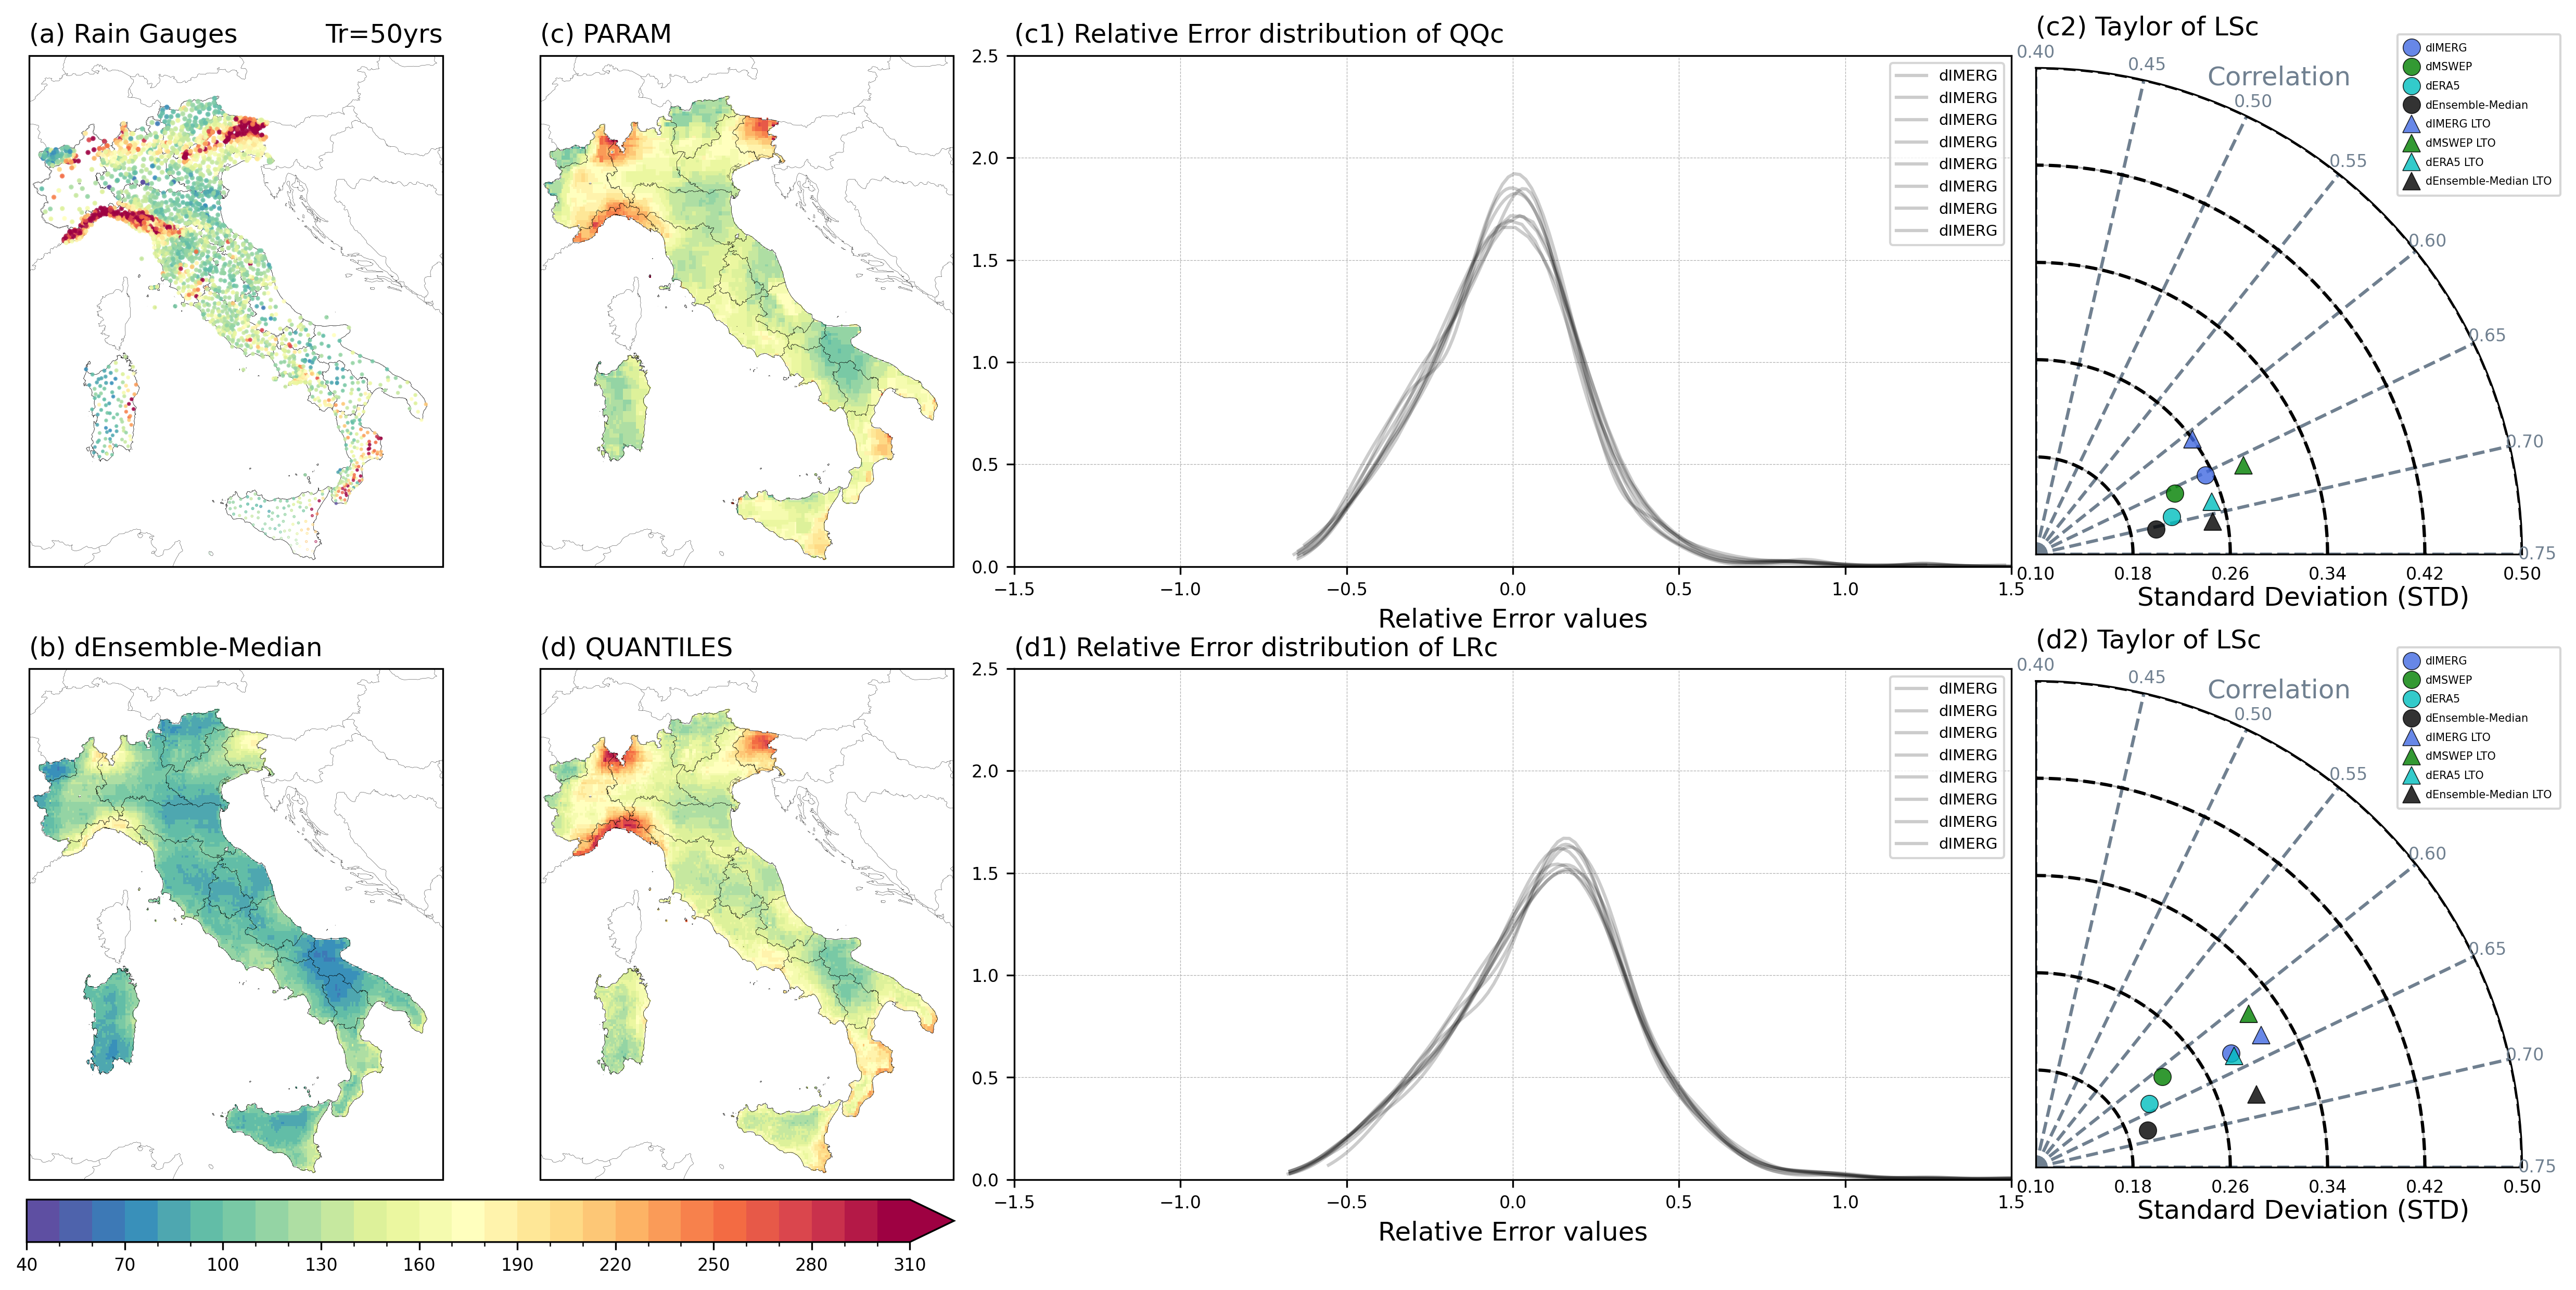

In [17]:
pos = 3

proj = ccrs.PlateCarree()

Mev_cmap = plt.cm.Spectral_r
diff_map = plt.cm.coolwarm_r
norm = mcolors.BoundaryNorm(boundaries=Mev_levels, ncolors=Mev_cmap.N)
# norm_diff = mcolors.BoundaryNorm(boundaries=Diff_levels, ncolors=diff_map.N)

fig = plt.figure(figsize=(18,8),dpi=300)
gs = gridspec.GridSpec(2,5)

# ===========================================================================================================================================================================
# ===========================================================================================================================================================================
ax1 = plt.subplot(gs[0, 0], projection = proj)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ax1.add_feature(cfeature.COASTLINE,linewidth=0.1,edgecolor='k')
ax1.add_feature(cfeature.BORDERS,linewidth=0.1,edgecolor='black',zorder=4)
im = REGIONS.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.1, ax=ax1, zorder=10)
a1 = ax1.scatter(Quantile_clear['lon'].values, Quantile_clear['lat'].values, c=Quantile_clear['Quantile'].values, s=Q_norm, alpha=0.8,cmap=Mev_cmap,norm=norm, zorder=10)

ax1.set_title('(a) Rain Gauges', loc='left', fontsize=12)
ax1.set_title('Tr=50yrs', loc='right', fontsize=12)

# ===========================================================================================================================================================================
ax1 = plt.subplot(gs[0, 1], projection = proj)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ax1.add_feature(cfeature.COASTLINE,linewidth=0.1,edgecolor='k')
ax1.add_feature(cfeature.BORDERS,linewidth=0.1,edgecolor='black',zorder=4)
im = REGIONS.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.1, ax=ax1, zorder=10)
# DEM.plot(facecolor='None', edgecolor='k', ax=ax1, linewidth=0.1, zorder=21, alpha=0.3)
a1 = ax1.pcolormesh(lon2d, lat2d, MEVd_LTO_PARAM, cmap=Mev_cmap, norm=norm)

# cbar = plt.colorbar(a1, ax=ax1, fraction=0.056, pad=0.04, orientation='horizontal')
# cbar.ax.tick_params(labelsize=6) 

ax1.set_title('(c) PARAM', loc='left', fontsize=12)

# ===========================================================================================================================================================================
ax1 = plt.subplot(gs[0, 2:4])
ax1.set_aspect('auto')
for nn in range(len(seeds_list)):
    sns.kdeplot(ENSEMBLE_group_PARAM[nn],color='k',cumulative=False,fill=False,multiple="stack",ax=ax1,label=f'dIMERG',
            clip=(np.nanmin(np.array(ENSEMBLE_group_PARAM[nn])), np.nanmax(np.array(ENSEMBLE_group_PARAM[nn]))), alpha=0.2)
# sns.kdeplot(DF_RE.IMERG,color=colors[0],cumulative=False,fill=False,multiple="stack",ax=ax1,label=f'dIMERG',
#             clip=(np.nanmin(np.array(DF_RE.IMERG)), np.nanmax(np.array(DF_RE.IMERG))))
# sns.kdeplot(DF_RE.MSWEP,color=colors[2],cumulative=False,fill=False,multiple="stack",ax=ax1,label=f'dMSWEP',
#             clip=(np.nanmin(np.array(DF_RE.MSWEP)), np.nanmax(np.array(DF_RE.MSWEP))))
# sns.kdeplot(DF_RE.ERA5,color=colors[3],cumulative=False,fill=False,multiple="stack",ax=ax1,label=f'dERA5',
#             clip=(np.nanmin(np.array(DF_RE.ERA5)), np.nanmax(np.array(DF_RE.ERA5))))
# sns.kdeplot(DF_RE.ENSEMBLE_MEDIAN,color='k',cumulative=False,fill=False,multiple="stack",ax=ax1,label=f'dEnsemble-Median',
#             clip=(np.nanmin(np.array(DF_RE.ENSEMBLE_MEDIAN)), np.nanmax(np.array(DF_RE.ENSEMBLE_MEDIAN))))

# sns.kdeplot(DF_RE.IMERG_LLc,color=colors[0], linestyle='--',cumulative=False,fill=False,multiple="stack",ax=ax1,label=f'dIMERG-LLc',
#             clip=(np.nanmin(np.array(DF_RE.IMERG_LLc)), np.nanmax(np.array(DF_RE.IMERG_LLc))))
# sns.kdeplot(DF_RE.MSWEP_LLc,color=colors[2], linestyle='--',cumulative=False,fill=False,multiple="stack",ax=ax1,label=f'dMSWEP-LLc',
#             clip=(np.nanmin(np.array(DF_RE.MSWEP_LLc)), np.nanmax(np.array(DF_RE.MSWEP_LLc))))
# sns.kdeplot(DF_RE.ERA5_LLc,color=colors[3], linestyle='--',cumulative=False,fill=False,multiple="stack",ax=ax1,label=f'dERA5-LLc',
#             clip=(np.nanmin(np.array(DF_RE.ERA5_LLc)), np.nanmax(np.array(DF_RE.ERA5_LLc))))
# sns.kdeplot(DF_RE.ENSEMBLE_MEDIAN_LLc,color='k', linestyle='--',cumulative=False,fill=False,multiple="stack",ax=ax1,label=f'dEnsemble-Median-LLc',
#             clip=(np.nanmin(np.array(DF_RE.ENSEMBLE_MEDIAN_LLc)), np.nanmax(np.array(DF_RE.ENSEMBLE_MEDIAN_LLc))))

ax1.set_ylabel('',fontsize=12)
ax1.set_xlabel('Relative Error values',fontsize=12)
ax1.legend(fontsize=7, loc=0, ncol=1)
ax1.grid(linewidth=0.3, linestyle='--')
ax1.set_xlim(-1.5,1.5)
ax1.set_ylim(0,2.5)
ax1.tick_params(axis='both', which='major', labelsize=8)

ax1.set_title('(c1) Relative Error distribution of QQc', loc='left', fontsize=12)

# ===========================================================================================================================================================================
ax1 = plt.subplot(gs[0, 4], polar=True)

rmin = 0.1
rmax = 0.5

c_min = 0.4
c_max = 0.75
correlations = np.arange(c_min, c_max + 0.05, 0.05)

for c in correlations:
    theta = (c_max - c) / (c_max - c_min) * (np.pi/2)
    ax1.plot([theta, theta], [rmin, rmax], color="slategrey", linestyle="--")
    ax1.text(theta, rmax * 1.025, f"{c:.2f}", ha="center", va="center",
            fontsize=8, color="slategrey")

# --- NUEVOS CÍRCULOS RADIALES DE MARE ---
radial_ticks = np.linspace(rmin, rmax, 6)
for r in radial_ticks:
    ax1.plot(np.linspace(0, np.pi/2, 200), np.ones(200)*r, color="k", linestyle="--")

# --- LIMPIEZA DE EJE ANGULAR ---
ax1.xaxis.set_visible(False)

# --- PUNTOS DE MODELOS ---
for rmse_val, corr_val, lab, co, ma in zip(RSR_PARAM_LTO.STD.values, RSR_PARAM_LTO.CORR.values, RSR_PARAM_LTO.Dataset.values, colors_T, markers_T):
    theta = (c_max - corr_val) / (c_max - c_min) * (np.pi/2)
    ax1.plot(theta, rmse_val, ma, markersize=8, 
            markeredgecolor='black',
            markeredgewidth=0.4,
            alpha=0.8, label=f'{lab}', color=co)

# --- LÍMITES Y DIRECCIÓN ---
ax1.set_thetamin(0)
ax1.set_thetamax(90)
ax1.set_theta_zero_location("E")
ax1.set_theta_direction(1)
ax1.set_rmin(rmin)
ax1.set_rmax(rmax)

# --- RADIAL TICKS ---
ax1.set_yticks(radial_ticks)
ax1.tick_params(axis='both', which='major', labelsize=8, pad=2)
ax1.grid(True)

plt.legend(fontsize=5, 
            ncol=1, 
            loc='upper right', 
            bbox_to_anchor=(1.09, 1.08),
            handlelength=1.0,      # Longitud de la línea del símbolo
            handletextpad=0.8,     # Espacio entre símbolo y texto
            borderpad=0.8,         # Padding interno
            labelspacing=0.8)      # Espacio entre etiquetas

ax1.text(0.55, -0.09, "Standard Deviation (STD)", transform=ax1.transAxes,ha="center", va="center", fontsize=12)

ax1.text(0.5, 0.98, "Correlation", transform=ax1.transAxes,
        ha="center", va="center", rotation=0, fontsize=12, color='slategrey')

ax1.set_title('(c2) Taylor of LSc', loc='left', fontsize=12, pad=15)

# ===========================================================================================================================================================================
# ===========================================================================================================================================================================
ax1 = plt.subplot(gs[1, 0], projection = proj)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ax1.add_feature(cfeature.COASTLINE,linewidth=0.1,edgecolor='k')
ax1.add_feature(cfeature.BORDERS,linewidth=0.1,edgecolor='black',zorder=4)
im = REGIONS.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.1, ax=ax1, zorder=10)
# DEM.plot(facecolor='None', edgecolor='k', ax=ax1, linewidth=0.1, zorder=21, alpha=0.3)
a1 = ax1.pcolormesh(lon2d, lat2d, MEVd_Median[pos,:,:], cmap=Mev_cmap, norm=norm)

# cbar = plt.colorbar(a1, ax=ax1, fraction=0.056, pad=0.04, orientation='horizontal')
# cbar.ax.tick_params(labelsize=6) 

ax1.set_title('(b) dEnsemble-Median', loc='left', fontsize=12)


# ===========================================================================================================================================================================
ax1 = plt.subplot(gs[1, 1], projection = proj)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ax1.add_feature(cfeature.COASTLINE,linewidth=0.1,edgecolor='k')
ax1.add_feature(cfeature.BORDERS,linewidth=0.1,edgecolor='black',zorder=4)
im = REGIONS.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.1, ax=ax1, zorder=10)
# DEM.plot(facecolor='None', edgecolor='k', ax=ax1, linewidth=0.1, zorder=21, alpha=0.3)
a1 = ax1.pcolormesh(lon2d, lat2d, MEVd_LTO_QUANTILES, cmap=Mev_cmap, norm=norm)

# cbar = plt.colorbar(a1, ax=ax1, fraction=0.056, pad=0.04, orientation='horizontal')
# cbar.ax.tick_params(labelsize=6) 

ax1.set_title('(d) QUANTILES', loc='left', fontsize=12)

# ===========================================================================================================================================================================
ax1 = plt.subplot(gs[1, 2:4])
for nn in range(len(seeds_list)):
    sns.kdeplot(ENSEMBLE_group_QUANTILES[nn,:],color='k',cumulative=False,fill=False,multiple="stack",ax=ax1,label=f'dIMERG',
            clip=(np.nanmin(np.array(ENSEMBLE_group_QUANTILES[nn,:])), np.nanmax(np.array(ENSEMBLE_group_QUANTILES[nn,:]))), alpha=0.2)
# sns.kdeplot(DF_RE.IMERG,color=colors[0],cumulative=False,fill=False,multiple="stack",ax=ax1,label=f'dIMERG',
#             clip=(np.nanmin(np.array(DF_RE.IMERG)), np.nanmax(np.array(DF_RE.IMERG))))
# sns.kdeplot(DF_RE.MSWEP,color=colors[2],cumulative=False,fill=False,multiple="stack",ax=ax1,label=f'dMSWEP',
#             clip=(np.nanmin(np.array(DF_RE.MSWEP)), np.nanmax(np.array(DF_RE.MSWEP))))
# sns.kdeplot(DF_RE.ERA5,color=colors[3],cumulative=False,fill=False,multiple="stack",ax=ax1,label=f'dERA5',
#             clip=(np.nanmin(np.array(DF_RE.ERA5)), np.nanmax(np.array(DF_RE.ERA5))))
# sns.kdeplot(DF_RE.ENSEMBLE_MEDIAN,color='k',cumulative=False,fill=False,multiple="stack",ax=ax1,label=f'dEnsemble-Median',
#             clip=(np.nanmin(np.array(DF_RE.ENSEMBLE_MEDIAN)), np.nanmax(np.array(DF_RE.ENSEMBLE_MEDIAN))))

# sns.kdeplot(DF_RE.IMERG_LSc,color=colors[0], linestyle='--',cumulative=False,fill=False,multiple="stack",ax=ax1,label=f'dIMERG-LSc',
#             clip=(np.nanmin(np.array(DF_RE.IMERG_LSc)), np.nanmax(np.array(DF_RE.IMERG_LSc))))
# sns.kdeplot(DF_RE.MSWEP_LSc,color=colors[2], linestyle='--',cumulative=False,fill=False,multiple="stack",ax=ax1,label=f'dMSWEP-LSc',
#             clip=(np.nanmin(np.array(DF_RE.MSWEP_LSc)), np.nanmax(np.array(DF_RE.MSWEP_LSc))))
# sns.kdeplot(DF_RE.ERA5_LSc,color=colors[3], linestyle='--',cumulative=False,fill=False,multiple="stack",ax=ax1,label=f'dERA5-LSc',
#             clip=(np.nanmin(np.array(DF_RE.ERA5_LSc)), np.nanmax(np.array(DF_RE.ERA5_LSc))))
# sns.kdeplot(DF_RE.ENSEMBLE_MEDIAN_LSc,color='k', linestyle='--',cumulative=False,fill=False,multiple="stack",ax=ax1,label=f'dEnsemble-Median-LSc',
#             clip=(np.nanmin(np.array(DF_RE.ENSEMBLE_MEDIAN_LSc)), np.nanmax(np.array(DF_RE.ENSEMBLE_MEDIAN_LSc))))

ax1.set_ylabel('',fontsize=12)
ax1.set_xlabel('Relative Error values',fontsize=12)
ax1.legend(fontsize=7, loc=0, ncol=1)
ax1.grid(linewidth=0.3, linestyle='--')
ax1.set_xlim(-1.5,1.5)
ax1.set_ylim(0,2.5)
ax1.tick_params(axis='both', which='major', labelsize=8)

ax1.set_title('(d1) Relative Error distribution of LRc', loc='left', fontsize=12)

# =========================================================================================================================
ax1 = plt.subplot(gs[1, 4], polar=True)

rmin = 0.1
rmax = 0.5

c_min = 0.4
c_max = 0.75
correlations = np.arange(c_min, c_max + 0.05, 0.05)

for c in correlations:
    theta = (c_max - c) / (c_max - c_min) * (np.pi/2)
    ax1.plot([theta, theta], [rmin, rmax], color="slategrey", linestyle="--")
    ax1.text(theta, rmax * 1.025, f"{c:.2f}", ha="center", va="center",
            fontsize=8, color="slategrey")

# --- NUEVOS CÍRCULOS RADIALES DE MARE ---
radial_ticks = np.linspace(rmin, rmax, 6)
for r in radial_ticks:
    ax1.plot(np.linspace(0, np.pi/2, 200), np.ones(200)*r, color="k", linestyle="--")

# --- LIMPIEZA DE EJE ANGULAR ---
ax1.xaxis.set_visible(False)

# --- PUNTOS DE MODELOS ---
for rmse_val, corr_val, lab, co, ma in zip(RSR_QUANTILE_LTO.STD.values, RSR_QUANTILE_LTO.CORR.values, RSR_QUANTILE_LTO.Dataset.values, colors_T, markers_T):
    theta = (c_max - corr_val) / (c_max - c_min) * (np.pi/2)
    ax1.plot(theta, rmse_val, ma, markersize=8, 
            markeredgecolor='black',
            markeredgewidth=0.4,
            alpha=0.8, label=f'{lab}', color=co)

# --- LÍMITES Y DIRECCIÓN ---
ax1.set_thetamin(0)
ax1.set_thetamax(90)
ax1.set_theta_zero_location("E")
ax1.set_theta_direction(1)
ax1.set_rmin(rmin)
ax1.set_rmax(rmax)

# --- RADIAL TICKS ---
ax1.set_yticks(radial_ticks)
ax1.tick_params(axis='both', which='major', labelsize=8, pad=2)
ax1.grid(True)

plt.legend(fontsize=5, 
            ncol=1, 
            loc='upper right', 
            bbox_to_anchor=(1.09, 1.08),
            handlelength=1.0,      # Longitud de la línea del símbolo
            handletextpad=0.8,     # Espacio entre símbolo y texto
            borderpad=0.8,         # Padding interno
            labelspacing=0.8)      # Espacio entre etiquetas

# --- LABELS ---
ax1.text(0.55, -0.09, "Standard Deviation (STD)", transform=ax1.transAxes,ha="center", va="center", fontsize=12)

ax1.text(0.5, 0.98, "Correlation", transform=ax1.transAxes,
        ha="center", va="center", rotation=0, fontsize=12, color='slategrey')

ax1.set_title('(d2) Taylor of LSc', loc='left', fontsize=12, pad=15)

# ===========================================================================================================================================================================
plt.subplots_adjust(left=0.05, bottom=0.05, right=0.95, top=0.95, wspace=0.05, hspace=0.2)

cbar_ax = fig.add_axes([0.062, 0.0, 0.33, 0.034])
cbar = fig.colorbar(a1, cax=cbar_ax, orientation='horizontal', extend='max')
cbar.ax.tick_params(labelsize=8)

# cbar_ax = fig.add_axes([0.66, 0.09, 0.29, 0.038])
# cbar = fig.colorbar(a2, cax=cbar_ax, orientation='horizontal')
# cbar.ax.tick_params(labelsize=8)

# ===========================================================================================================================================================================
salida = '../figures/Article_down/Bias_correction_QUANTILES_ALL.png'
print(salida)
# plt.savefig(salida,transparent = False,bbox_inches ='tight',pad_inches = 0.1, facecolor=None)